# SAM 3 + Parser de Intención — Segmentación Zero-Shot de Daños

**Autores:**
+ Alvaro Marro Dorado
+ Juan Manuel Piedrabuena Marañón
+ Mynor Hernández Montero

**Repo Fase 1:** [FinalMasterProject_CarDamageDetection](https://github.com/Mynozy/FinalMasterProject_CarDamageDetection)


# Resumen

Este notebook implementa dos componentes del pipeline de detección de daños vehiculares:

**Parser de Intención (NLP):** convierte lenguaje natural en español (incluyendo vocabulario coloquial) en una estructura de datos con las clases de daño a buscar y la zona del auto mencionada. Usa Gemini con respuesta estructurada vía Pydantic.

**SAM 3 Zero-Shot:** segmenta instancias de daño usando prompts de texto, sin necesidad de fine-tuning. Detecta contornos precisos a nivel de píxel para cada clase identificada por el parser.

Ambos componentes se conectan para formar un sub-pipeline: `prompt_usuario → parse_intent → detectar_desde_intencion → visualizar_detecciones`.

En el `03_pipeline_completo` este sub-pipeline se integra con YOLO26 para mejorar la localización de daños que SAM 3 no detecta bien en zero-shot (especialmente dents).


# ¿Por qué SAM 3 y no solo YOLO26?

YOLO26 y SAM 3 resuelven problemas distintos y se complementan:

**YOLO26** es un detector — dice *dónde* está el daño y *qué* clase es, con una caja delimitadora. Fue fine-tuneado sobre nuestro dataset, así que conoce exactamente cómo se ve un scratch o un dent en autos de rental. Su limitación es que la salida es una caja rectangular, no el contorno exacto del daño.

**SAM 3** es un segmentador — dado un prompt de texto, encuentra y delimita *todos los píxeles* que pertenecen a ese concepto visual. Es zero-shot: no necesita fine-tuning. Su limitación es que depende del prompt textual para conceptos visuales ambiguos como "dent".

En el pipeline final los usamos en serie: YOLO26 localiza el daño, SAM 3 genera el contorno exacto. Este notebook construye y prueba la parte de SAM 3 de forma independiente.


# Setup — Entorno y Dependencias

In [1]:
import torch

# Verificamos que el entorno tiene lo necesario para SAM 3
# necesita al menos 8GB de VRAM para correr sin problemas
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM disponible: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")

import ultralytics
print(f"ultralytics: {ultralytics.__version__}")

GPU: Tesla T4
VRAM total: 15.6 GB
VRAM disponible: 15.6 GB
ultralytics: 8.4.75


In [1]:
# ultralytics ya incluye SAM 3 desde 8.3.x — no hay que instalarlo aparte
# fix de CLIP que SAM 3 usa internamente para prompts de texto
!pip uninstall clip -y -q
!pip install git+https://github.com/ultralytics/CLIP.git -q

# downgrade de pydantic necesario para compatibilidad con google-genai 2.9.0
# pydantic 2.12+ rompe el response_schema del SDK con polymorphic_serialization
!pip install "pydantic==2.10.6" -q

print("Dependencias instaladas")

Dependencias instaladas


# Autenticación y Pesos

In [1]:
from huggingface_hub import login
from google.colab import userdata, drive

# Montamos Drive para leer los pesos de SAM 3 guardados previamente
drive.mount('/content/drive')

# Token de HuggingFace guardado en Colab Secrets como HFToken
# Necesitas acceso aprobado a facebook/sam3 en HuggingFace
login(token=userdata.get('HFToken'))

Mounted at /content/drive


In [1]:
import os
from huggingface_hub import hf_hub_download

# los pesos de SAM 3 pesan ~2.4GB — los guardamos en Drive para no bajarlos cada vez
SAVE_DIR  = '/content/drive/MyDrive/sam3_weights'
CKPT_PATH = f'{SAVE_DIR}/sam3.pt'

os.makedirs(SAVE_DIR, exist_ok=True)

if os.path.exists(CKPT_PATH):
    print(f"Pesos encontrados en Drive, saltando descarga: {CKPT_PATH}")
else:
    print("Descargando pesos de SAM 3 desde HuggingFace (~2.4GB)...")
    hf_hub_download(
        repo_id='facebook/sam3',
        filename='sam3.pt',
        local_dir=SAVE_DIR
    )
    print(f"Pesos guardados en: {CKPT_PATH}")

Pesos encontrados en Drive, saltando descarga: /content/drive/MyDrive/sam3_weights/sam3.pt


# Carga del Modelo — SAM3SemanticPredictor

SAM 3 tiene varias interfaces según el tipo de prompt:

- `SAM` con puntos/cajas → segmenta el objeto en esa ubicación (igual que SAM 2)
- `SAM3SemanticPredictor` con texto → encuentra **todas** las instancias del concepto en la imagen

Usamos `SAM3SemanticPredictor` porque queremos encontrar todos los scratches o dents presentes, no solo el que está en una coordenada específica. El path del modelo va en los `overrides` — no en `setup_model` como en SAM 2.


In [1]:
from ultralytics.models.sam import SAM3SemanticPredictor

# el path del modelo va en overrides, no en setup_model
# conf: mínimo de confianza para reportar una detección
# iou: threshold para fusionar máscaras solapadas del mismo daño
overrides = dict(
    model=CKPT_PATH,
    conf=0.5,
    iou=0.5,
    imgsz=1024
)
predictor = SAM3SemanticPredictor(overrides=overrides)

print("SAM 3 cargado y listo")

SAM 3 cargado y listo


# Carga de Imagen

Las fotos de inspección vienen frecuentemente de móvil y tienen rotación EXIF incorrecta — se ven bien en el teléfono pero al leerlas con PIL aparecen rotadas. `ImageOps.exif_transpose` corrige eso automáticamente antes de pasarla al predictor.


In [1]:
import numpy as np
from PIL import Image, ImageOps
from google.colab import files

def preparar_imagen(path):
    # carga la imagen y corrige rotación EXIF — frecuente en fotos de móvil
    img = Image.open(path).convert('RGB')
    img = ImageOps.exif_transpose(img)
    return np.array(img)

uploaded = files.upload()
img_path = list(uploaded.keys())[0]
image = preparar_imagen(img_path)

print(f"Imagen cargada: {img_path}")
print(f"Shape: {image.shape}")

Imagen cargada: Car-Paintwork-Damage-.jpg
Shape: (1062, 1700, 3)


# Test de SAM 3 — Detección Directa

Antes de conectar el parser, probamos SAM 3 directamente con un prompt de texto para verificar que el modelo detecta correctamente.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

COLORES_POR_CLASE = {
    "scratch":       (0.2, 0.6, 1.0),
    "dent":          (1.0, 0.4, 0.2),
    "crack":         (0.9, 0.9, 0.1),
    "glass shatter": (0.2, 0.9, 0.5),
    "rust":          (0.7, 0.3, 0.1),
    "paint damage":  (0.8, 0.2, 0.8),
}

# test directo con prompt de texto — los prompts van via predictor.prompts
predictor.prompts = {"text": ["scratch"]}
results = predictor(source=image)
print(f"Detecciones de scratch: {len(results[0].masks) if results[0].masks else 0}")

Detecciones de scratch: 15


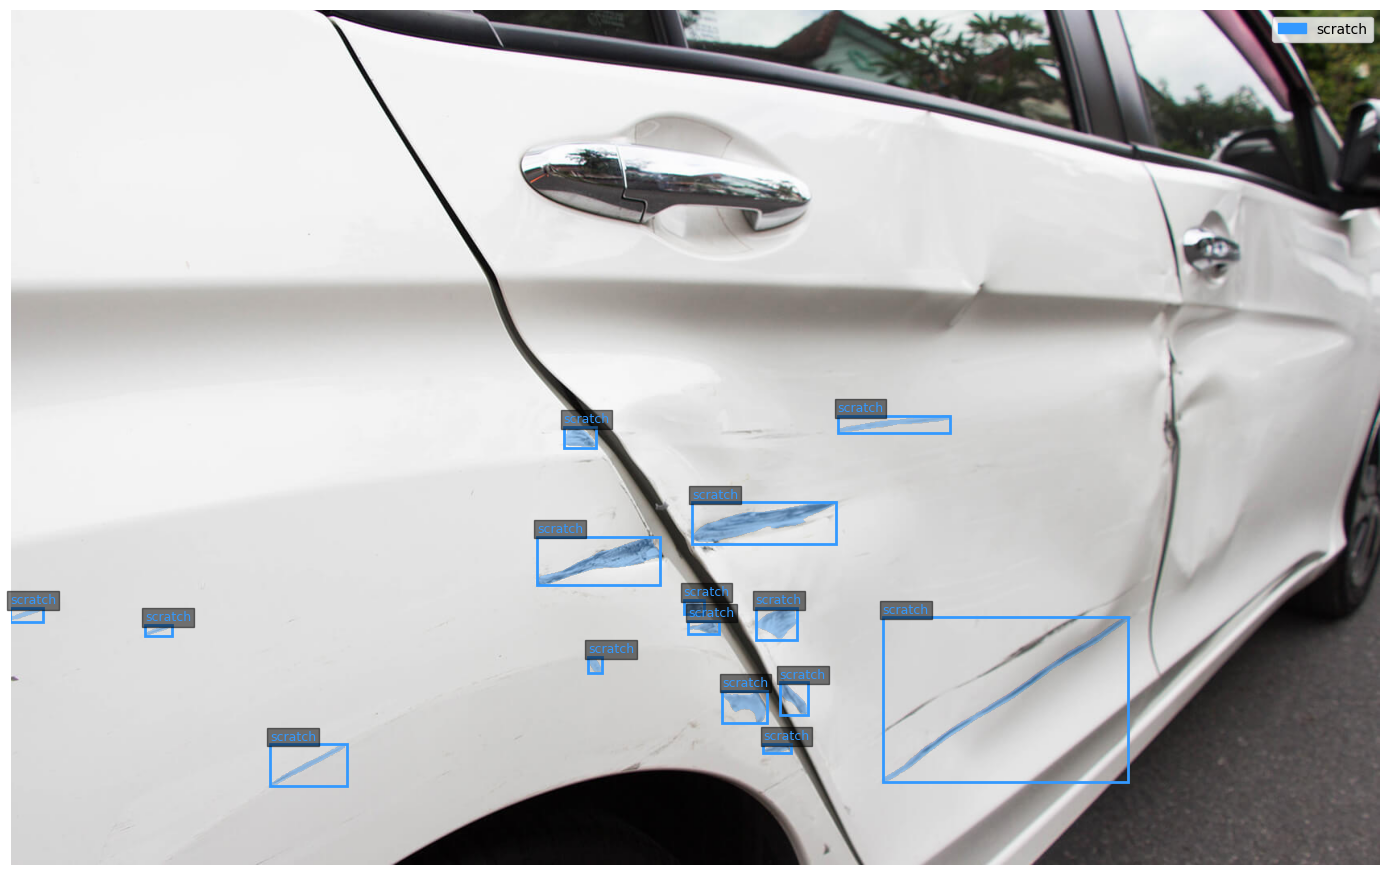

SAM 3 detecta 15 instancias de scratch con cajas rectangulares. Los scratches azules de pintura transferida en el centro son los más obvios. Se pueden ver algunos falsos positivos — líneas de diseño del auto y reflejos — que son el caso de uso del juez VLM en el pipeline completo.

# Parser de Intención — NLP con Gemini

El parser convierte lenguaje natural en una estructura de datos con las clases de daño a buscar y la zona del auto.

Usa `gemini-3.1-flash-lite` con `response_schema` de Pydantic para garantizar que la respuesta siempre viene en el formato correcto — sin parsear texto suelto. La taxonomía está cerrada: solo acepta las clases y zonas definidas en los enums.

**Nota de compatibilidad:** requiere `pydantic==2.10.6`. Las versiones 2.12+ tienen un conflicto con `google-genai 2.9.0` que rompe el `response_schema`.


In [1]:
from google import genai
from google.colab import userdata

# cliente de Gemini — se crea una sola vez y se reusa en cada llamada
# API key guardada en Colab Secrets como GeminiKey
client = genai.Client(api_key=userdata.get('GeminiKey'))
print("Cliente Gemini listo")

Cliente Gemini listo


In [1]:
from enum import StrEnum
from typing import Optional
from pydantic import BaseModel

# taxonomía cerrada de daños que soporta el pipeline
# StrEnum en vez de (str, Enum): desde Python 3.11 ese mixin imprime
# "ClaseDano.SCRATCH" en f-strings en vez del valor plano
class ClaseDano(StrEnum):
    SCRATCH      = "scratch"
    DENT         = "dent"
    BROKEN_GLASS = "glass shatter"
    CRACK        = "crack"
    RUST         = "rust"
    PAINT_DAMAGE = "paint damage"

# zonas opcionales del auto — si el usuario especifica dónde mirar
class ZonaAuto(StrEnum):
    DOOR       = "door"
    HOOD       = "hood"
    BUMPER     = "bumper"
    FENDER     = "fender"
    WINDSHIELD = "windshield"
    ROOF       = "roof"
    TRUNK      = "trunk"
    WHEEL      = "wheel"
    HEADLIGHT  = "headlight"
    MIRROR     = "mirror"

# schema de respuesta que Gemini debe respetar
class IntencionParseada(BaseModel):
    clases: list[ClaseDano]
    zona: Optional[ZonaAuto] = None

In [1]:
from google.genai import types

INSTRUCCIONES = """Eres un parser de intención para un sistema de detección de daños en autos.
Lee la petición del usuario (puede venir en español o ingles) e identifica
qué tipos de daño quiere buscar y, si lo menciona, en qué zona del auto.

Si el usuario pide "todos los daños" o algo similar, incluye todas las clases disponibles.
Si no menciona ninguna zona especifica, deja zona en null.
"""

def parse_intent(prompt_usuario):
    """
    le mando el prompt del usuario a gemini y me devuelve un IntencionParseada
    con la lista de clases y la zona (o None si no aplica)
    """
    try:
        response = client.models.generate_content(
            model="gemini-3.1-flash-lite",  # modelo liviano, perfecto pa esta tarea de clasificación
            contents=f"{INSTRUCCIONES}\n\nPetición del usuario: \"{prompt_usuario}\"",
            config=types.GenerateContentConfig(
                temperature=0,                  # nada de creatividad, quiero resultados consistentes
                response_mime_type="application/json",
                response_schema=IntencionParseada,
            ),
        )
        return IntencionParseada.model_validate_json(response.text)
    except Exception as e:
        print(f"Error parseando intención: {e}")
        return IntencionParseada(clases=[], zona=None)

In [1]:
# probamos con varios prompts en español, incluyendo vocabulario coloquial
prompts_de_prueba = [
    "revisa si hay rayones o vidrios rotos en la puerta",
    "quiero ver todos los daños del auto",
    "hay alguna abolladura en el cofre?",
    "checa si el parabrisas tiene grietas",
    "el auto tiene algo raro en la cajuela",
]

for prompt in prompts_de_prueba:
    resultado = parse_intent(prompt)
    print(f"prompt : {prompt}")
    print(f"clases : {resultado.clases}")
    print(f"zona   : {resultado.zona}")
    print()

prompt : revisa si hay rayones o vidrios rotos en la puerta
clases : [<ClaseDano.SCRATCH: 'scratch'>, <ClaseDano.BROKEN_GLASS: 'glass shatter'>]
zona   : door

prompt : quiero ver todos los daños del auto
clases : [<ClaseDano.SCRATCH: 'scratch'>, <ClaseDano.DENT: 'dent'>, <ClaseDano.BROKEN_GLASS: 'glass shatter'>, <ClaseDano.CRACK: 'crack'>, <ClaseDano.RUST: 'rust'>, <ClaseDano.PAINT_DAMAGE: 'paint damage'>]
zona   : None

prompt : hay alguna abolladura en el cofre?
clases : [<ClaseDano.DENT: 'dent'>]
zona   : hood

prompt : checa si el parabrisas tiene grietas
clases : [<ClaseDano.CRACK: 'crack'>]
zona   : windshield

prompt : el auto tiene algo raro en la cajuela
clases : [<ClaseDano.SCRATCH: 'scratch'>, <ClaseDano.DENT: 'dent'>, <ClaseDano.BROKEN_GLASS: 'glass shatter'>, <ClaseDano.CRACK: 'crack'>, <ClaseDano.RUST: 'rust'>, <ClaseDano.PAINT_DAMAGE: 'paint damage'>]
zona   : trunk


# SAM 3 Multi-Clase

Con el parser funcionando, construimos las funciones que conectan la intención parseada con SAM 3:

- `detectar_clase`: corre SAM 3 para una sola clase y devuelve lista de detecciones con máscara, caja y confianza
- `detectar_multi_clase`: itera sobre todas las clases de la intención
- `detectar_desde_intencion`: conecta `parse_intent` directo con la detección


In [1]:
def detectar_clase(predictor, clase):
    """
    corre SAM 3 para una sola clase de daño sobre la imagen ya cargada en el predictor
    devuelve lista de dicts con clase, mascara y caja por cada detección encontrada
    """
    predictor.prompts = {"text": [clase]}
    results = predictor(source=image)

    detecciones = []
    if results[0].masks is None:
        return detecciones

    for mask, box, conf in zip(
        results[0].masks.data,
        results[0].boxes.xyxy,
        results[0].boxes.conf
    ):
        detecciones.append({
            "clase":     clase,
            "mascara":   mask.cpu().numpy(),
            "caja":      box.cpu().numpy(),
            "confianza": float(conf)
        })

    return detecciones

In [1]:
def detectar_multi_clase(predictor, clases):
    """
    corre detectar_clase para cada clase de la lista y junta todo en una sola lista
    """
    todas = []
    for clase in clases:
        detecciones = detectar_clase(predictor, clase)
        print(f"{clase}: {len(detecciones)} detecciones")
        todas.extend(detecciones)
    return todas


def detectar_desde_intencion(predictor, intencion):
    """
    toma el resultado de parse_intent y corre detectar_multi_clase con esas clases
    la zona por ahora se devuelve como dato informativo — no se usa pa recortar todavía
    """
    detecciones = detectar_multi_clase(predictor, intencion.clases)
    return detecciones, intencion.zona

# Visualización con Severidad

La severidad se calcula como el área de la máscara como porcentaje del total de píxeles de la imagen:

| Rango | Severidad |
|---|---|
| < 0.1% | bajo |
| < 0.5% | medio |
| ≥ 0.5% | alto |

**Nota de diseño:** estos umbrales son un punto de partida. En el `03_pipeline_completo` se calibran considerando el tipo de daño y el ángulo de la toma — un scratch largo pero delgado tiene área pequeña pero puede ser un daño significativo.

La visualización usa contornos exactos de la máscara (`skimage.measure.find_contours`) en vez de cajas rectangulares, para mostrar la forma real del daño.


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from skimage import measure

def calcular_severidad(mascara, imagen):
    # área de la máscara como porcentaje del total de píxeles de la imagen
    area_total = imagen.shape[0] * imagen.shape[1]
    area_dano  = float(mascara.sum())
    porcentaje = (area_dano / area_total) * 100

    if porcentaje < 0.1:
        return "bajo", porcentaje
    elif porcentaje < 0.5:
        return "medio", porcentaje
    else:
        return "alto", porcentaje

def visualizar_detecciones(image, detecciones):
    fig, ax = plt.subplots(1, 1, figsize=(14, 9))
    ax.imshow(image)

    clases_presentes = set()
    filas_tabla = []

    for i, det in enumerate(detecciones):
        clase    = det["clase"]
        mascara  = det["mascara"]
        color    = COLORES_POR_CLASE.get(clase, (0.5, 0.5, 0.5))
        severidad, pct = calcular_severidad(mascara, image)

        # overlay semitransparente de la máscara
        overlay = np.zeros((*mascara.shape, 4))
        overlay[mascara > 0] = [*color, 0.25]
        ax.imshow(overlay, extent=[0, image.shape[1], image.shape[0], 0])

        # contorno exacto de la máscara en vez de caja rectangular
        contornos = measure.find_contours(mascara, 0.5)
        for contorno in contornos:
            # find_contours devuelve (row, col) — hay que invertir a (x, y)
            ax.plot(contorno[:, 1], contorno[:, 0], color=color, linewidth=1.5)

        # label sobre el primer contorno si existe
        if contornos:
            y0, x0 = contornos[0][0]
            ax.text(x0, y0-5, f"{clase} | {severidad}",
                    color=color, fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.5, pad=2))

        clases_presentes.add(clase)
        filas_tabla.append({
            "id":        i + 1,
            "clase":     clase,
            "severidad": severidad,
            "área (%)":  round(pct, 3),
            "confianza": round(det["confianza"], 2)
        })

    # leyenda con solo las clases presentes en la imagen
    handles = [
        patches.Patch(color=COLORES_POR_CLASE.get(c, (0.5,0.5,0.5)), label=c)
        for c in clases_presentes
    ]
    ax.legend(handles=handles, loc='upper right', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # tabla de resumen de detecciones
    df = pd.DataFrame(filas_tabla)
    print("\nResumen de detecciones:")
    print(df.to_string(index=False))
    return df

# Prueba Integrada — Flujo Completo

Conectamos todo el pipeline del notebook: prompt de texto → parser de intención → SAM 3 multi-clase → visualización con contornos y tabla de severidad.

In [1]:
# flujo completo: texto del usuario → clases → SAM 3 → visualización + tabla
prompt_usuario = "revisa si hay rayones o abolladuras en la puerta"

print(f"Prompt: '{prompt_usuario}'")
print("-" * 50)

# paso 1: parseamos la intención
intencion = parse_intent(prompt_usuario)
print(f"Clases detectadas: {[str(c) for c in intencion.clases]}")
print(f"Zona: {intencion.zona}")
print("-" * 50)

# paso 2: corremos SAM 3 con las clases extraídas
detecciones, zona = detectar_desde_intencion(predictor, intencion)
print("-" * 50)

# paso 3: visualizamos y mostramos tabla
df = visualizar_detecciones(image, detecciones)

Prompt: 'revisa si hay rayones o abolladuras en la puerta'
--------------------------------------------------
Clases detectadas: ['scratch', 'dent']
Zona: door
--------------------------------------------------
scratch: 15 detecciones
dent: 3 detecciones
--------------------------------------------------


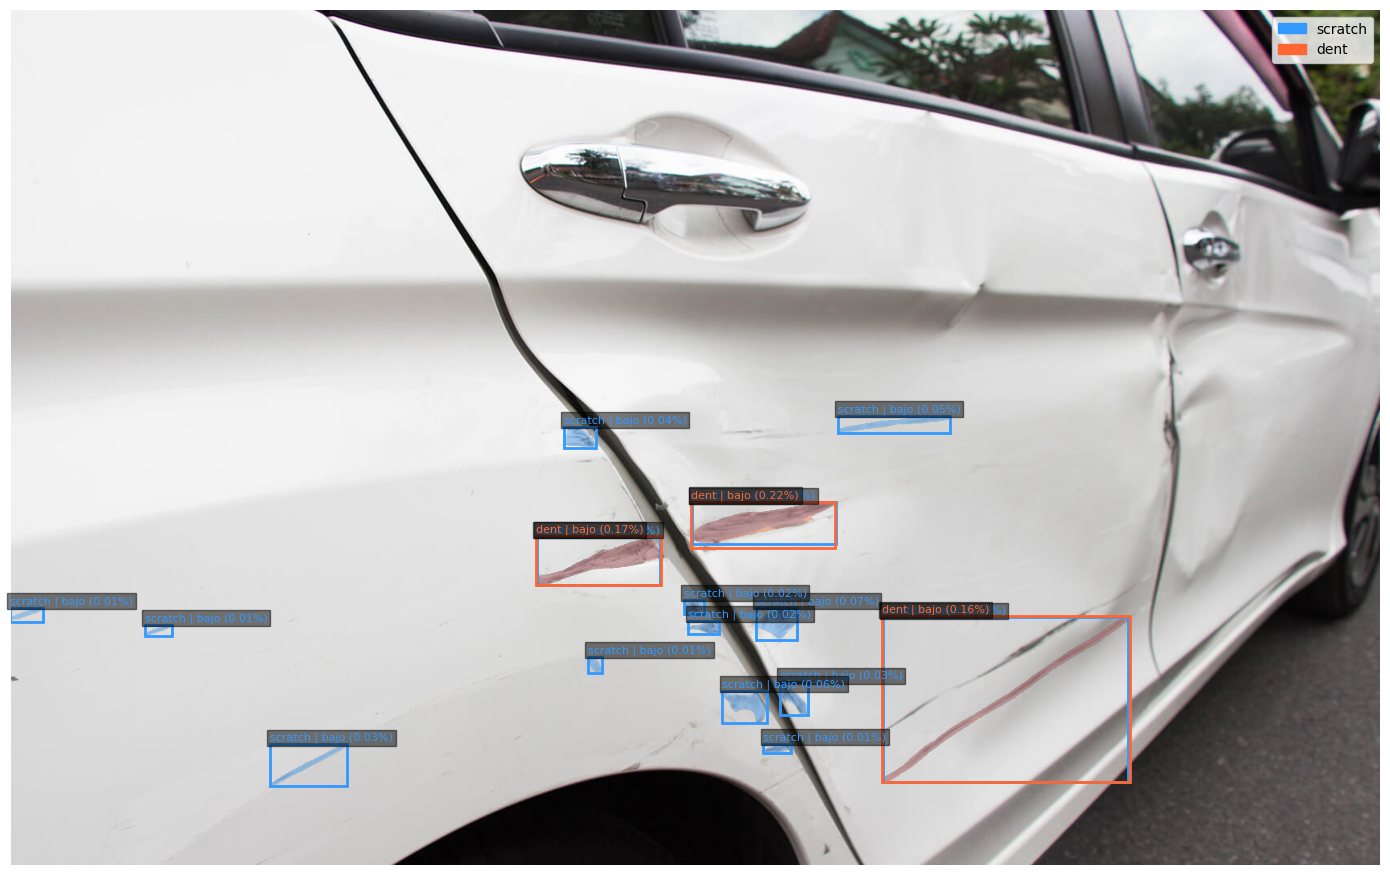

Visualización con contornos exactos de máscara y tabla de severidad. Los contornos azules corresponden a scratches y los naranjas a dents.

Los scratches lineales largos (derecha) son detectados con alta precisión — SAM 3 sigue el contorno real del rayón. Los dents (centro) se detectan en la zona de pintura transferida, aunque el abolladón grande de la derecha no es capturado — limitación del zero-shot que se resuelve en el pipeline completo con YOLO26.

Todos los daños salen con severidad "bajo" porque el área de cada instancia individual es menor al 0.1% de la imagen. Esto refleja que los daños son objetos pequeños, no que sean insignificantes — la calibración de umbrales se hace en el `03_pipeline_completo`.

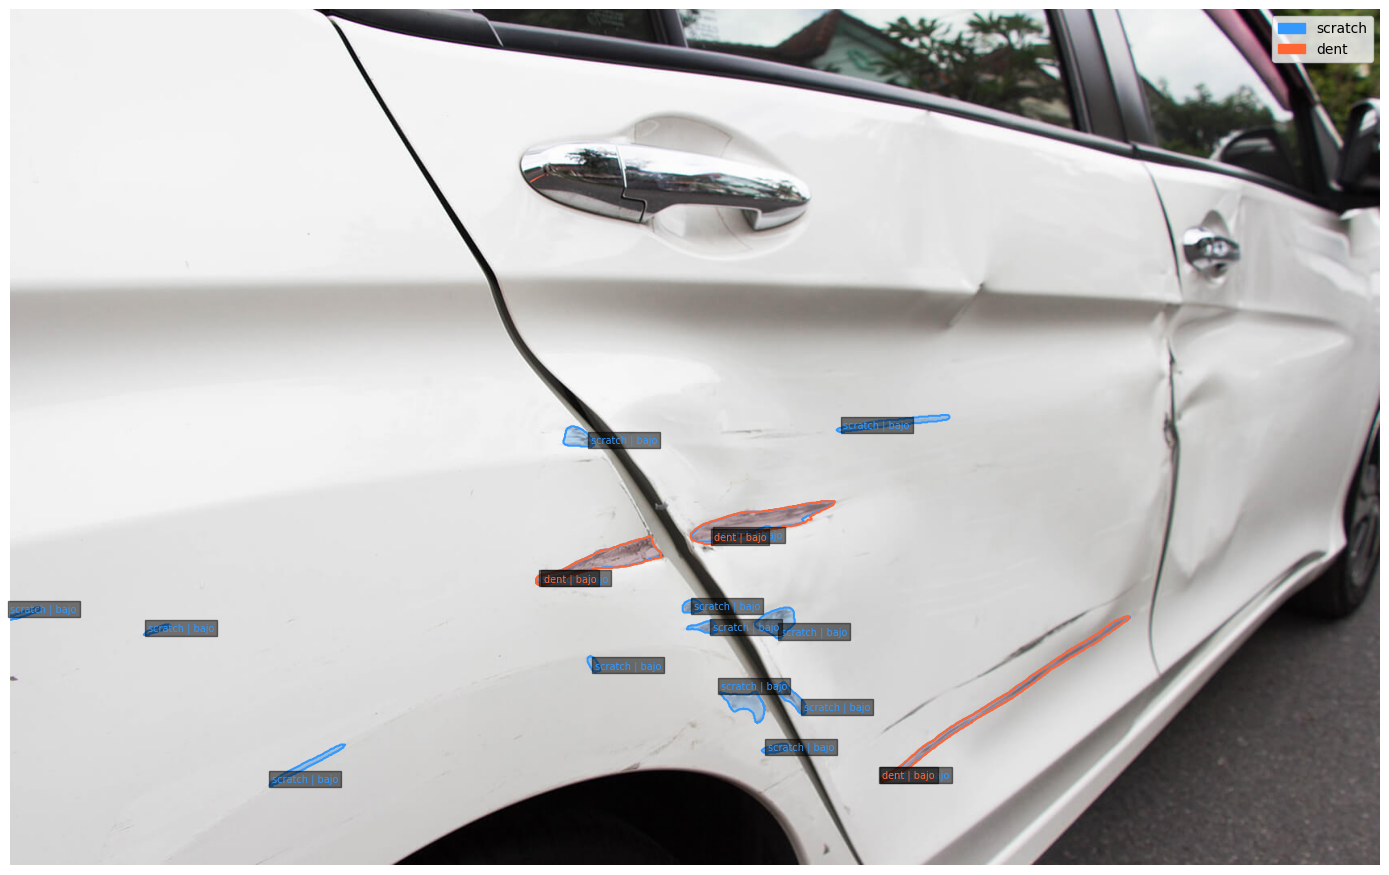

Resultado final de la prueba integrada con el prompt 'revisa si hay rayones o abolladuras en la puerta'. El parser extrae correctamente las clases scratch y dent, y la zona door. SAM 3 corre sobre ambas clases y visualiza los contornos con su severidad.

### Tabla de detecciones

| id | clase | severidad | área (%) | confianza |
|---|---|---|---|---|
| 1 | scratch | bajo | 0.160 | 0.79 |
| 2 | scratch | bajo | 0.147 | 0.78 |
| 3 | scratch | bajo | 0.198 | 0.73 |
| 4-15 | scratch | bajo | 0.008–0.066 | 0.51–0.71 |
| 16 | dent | bajo | 0.165 | 0.60 |
| 17 | dent | bajo | 0.161 | 0.54 |
| 18 | dent | bajo | 0.220 | 0.53 |

**Speed:** ~2.4s por clase en T4 (SAM 3 es más lento que YOLO26 por el tamaño del modelo). En el pipeline completo se optimiza corriendo YOLO26 primero y SAM 3 solo sobre las regiones detectadas.
